# Explainable Credit Risk Assessment #

## 1. Load the Data ##
*   We will bring in the loan applicant data.
*   This data has details like income, age, and loan amount.
*   It also tells us who repaid and who defaulted.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2. Exploratory Data Analysis (EDA) ##
*   Here we simply look at the data before touching it.
*   We want to understand it first, then work on it.


### Basic info about the data ###
*   Check how many rows and columns we have.
*   Check the data type of each column.

In [ ]:
df.shape

(32581, 12)

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


### Missing values ###
*   Find out which columns have empty or missing values.
*   This tells us where we may need to fix things later.

In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


### Target balance ###
*   Check how many people defaulted vs how many repaid.
*   This tells us if our data is balanced or imbalanced.

In [ ]:
df.head()
df['loan_status'].unique()

array([1, 0])

In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


<Axes: xlabel='loan_status', ylabel='count'>

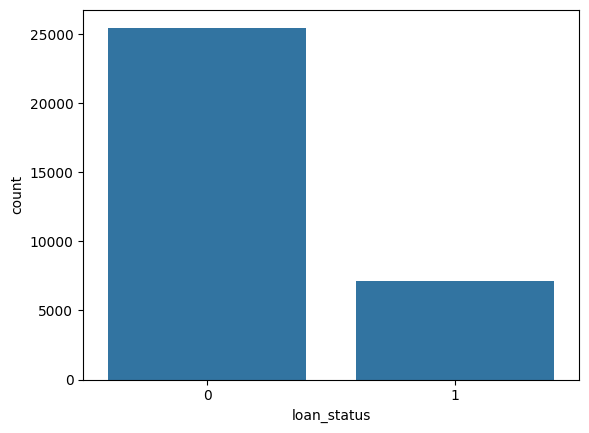

In [ ]:
sns.countplot(x='loan_status', data=df)

### Outlier check ###
*   Look for values that seem impossible, like age 144.
*   These are signs of bad data entries.

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [3]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

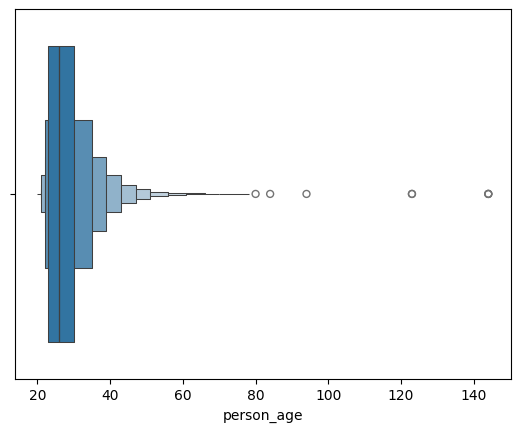

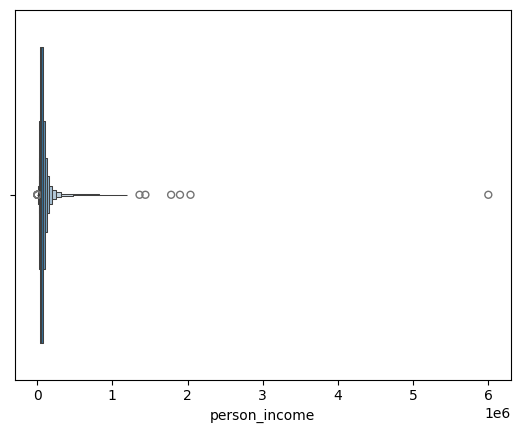

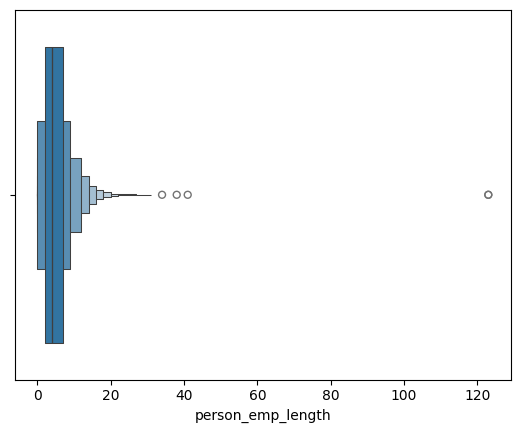

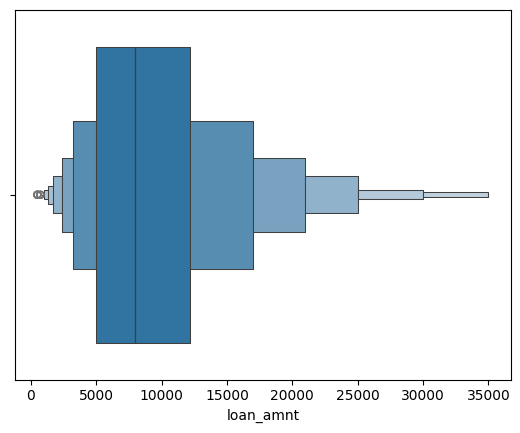

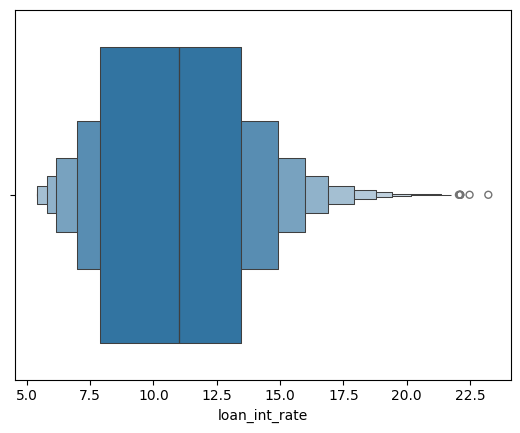

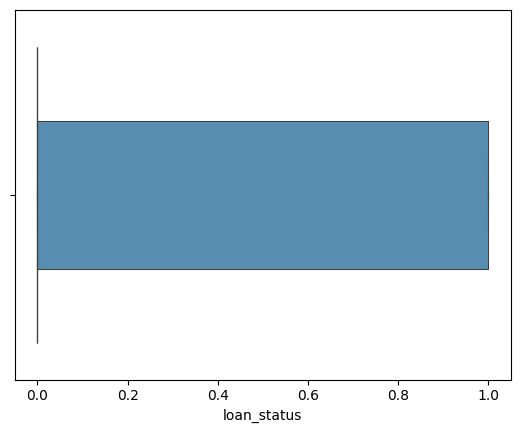

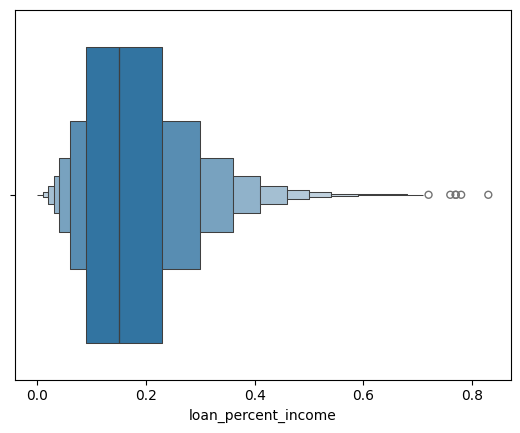

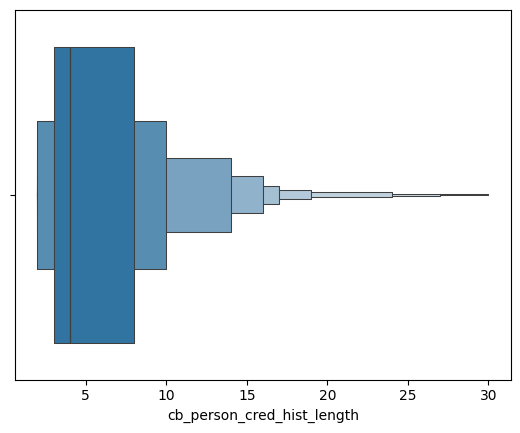

In [4]:
for i in numerical_cols:
  sns.boxenplot(x=df[i])
  plt.show()

In [ ]:
(df['person_age'] > 100).sum()

np.int64(5)

In [ ]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

### Correlation check ###
*   See how strongly features are related to each other.
*   This helps us spot repeated or linked information.

<Axes: >

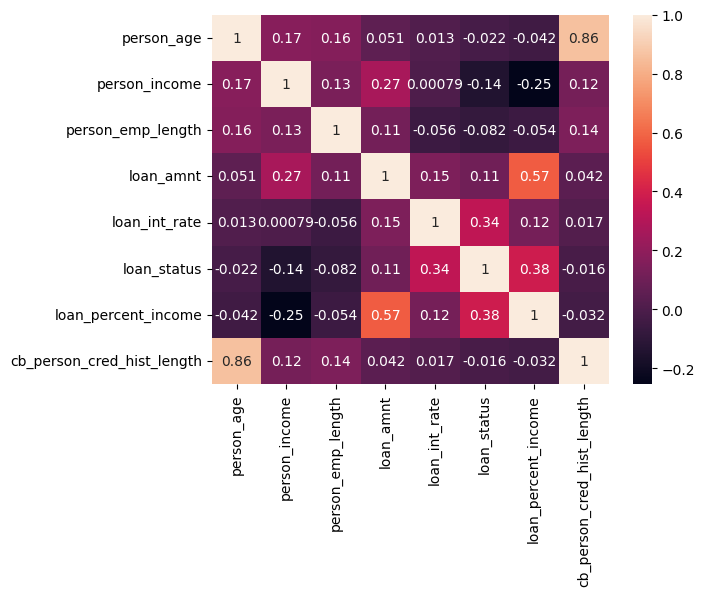

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### Basic info  ###
*   Check how many rows and columns we have.
*   Check the data type of each column.

## 3. Data Validation & Outlier Handling ##
*   Here we clean the data properly.
*   We remove duplicate rows.
*   We remove rows with an impossible age or work experience.
*   We remove rows with zero or negative income and loan amount.
*   We check if the interest rate looks realistic.
*   We also flag rows where numbers don't add up correctly.











In [5]:
df_copy = df.copy()

print(f"Original Rows: {df_copy.shape[0]}")

# Remove Duplicate Rows
df_copy.drop_duplicates(inplace=True)

print(f"Rows after removing duplicates: {df_copy.shape[0]}")

# Remove ages below 18 or above 100
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] <= 100]

# Remove employment length greater than age or extreme outlier (>60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

# Remove the rows with zero or negative income and loan amount.
df_copy = df_copy[df_copy['loan_amnt'] > 0]

# Check if the interest rate looks realistic
print("Loan interest rate range from (min: 5.42 and max: 23.22)")

Original Rows: 32581
Rows after removing duplicates: 32416
Loan interest rate range from (min: 5.42 and max: 23.22)


In [ ]:
df_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32411.000000,3.241100e+04,31524.000000,32411.000000,29317.000000,32411.000000,32411.000000,32411.000000
mean,27.730369,6.589796e+04,4.790350,9593.591682,11.017117,0.218722,0.170259,5.811052
std,6.210448,5.252093e+04,4.145566,6322.529723,3.241845,0.413386,0.106808,4.057816
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## 4. Features, Target & Train-Test Split ##
*   We separate the data into input features and the target.
*   The target is whether the applicant defaulted or not.
*   We split the data into a training part and a testing part.
*   The model learns from the training part only.

In [6]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

## 5. Handle Class Imbalance ##
*   Very few people actually default in this data.
*   If we ignore this, the model may just favor the majority class.
*   We give more importance to the minority class during training.
*   This helps the model actually learn to spot defaulters.

In [ ]:
# 0 -> no loan (most)
# 1 -> yes loan

y_train.value_counts()

,count
loan_status,
0,19772
1,5445


In [ ]:
np.bincount(y_train)

array([19772,  5445])

In [9]:
neg, pos = np.bincount(y_train)
scale_weights = neg/pos

In [10]:
scale_weights

np.float64(3.6312213039485766)

## 6. Data Preprocessing - Pipelines & Column Transformer ##
*   Raw data is not ready for a model directly.
*   We need to prepare numeric and text columns differently.
*   We will build a Pipeline for each model.
*   We will use ColumnTransformer to apply different steps to different columns.

### Preprocessing for Logistic Regression ###
*   Fill missing numeric values.
*   Scale numeric values, since this model is sensitive to scale.
*   Convert category columns into numbers using one-hot encoding.

In [11]:
# Logistic Regression: impute + SCALE Numeric, impute + One-Hot-Encoding

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        # Pipeline - for numerical cols
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        # Pipeline - for Categorical cols.
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

### Preprocessing for XGBoost ###
*   Fill missing numeric values.
*   No scalling needed here, since tree models don't need it.
*   Convert category columns into numbers using one-hot encoding.

In [12]:
# XGBoost : impute numeric only (No Scaling), impute + One-Hot-Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        # Pipeline - for numerical cols
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
        ]), numeric_cols),

        # Pipeline - for Categorical cols.
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

## 7. Evaluation Helper Function  ##
*   We build one common function to check any model's performance.
*   It will show accuracy, precision, recall, F1 score, and more.
*   It will also show a confusion matrix and a precision-recall curve.

In [21]:
# We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve

def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:, 1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  # Metrices
  accuracy = accuracy_score(y_test, y_pred) # Overall Model's Performance
  precision = precision_score(y_test, y_pred) # When the model says 1, how oftenly is it actually 1.
  recall = recall_score(y_test, y_pred) # Of the actual 1 how many did the model catches
  f1 = f1_score(y_test, y_pred) # Harmonic mean of precision and recall

  conf_matrix = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  print(f"{model_name} Metrics:")

  if threshold is not None: # Only print thresold if provided
    print(f"Used Thresold : {threshold:.2f}")
  print(f"Accuracy: {accuracy:.2f}")
  print(f"Precision: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1: {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)

  # Plotting confusion matrix
  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()

  # Plotting ROC-AUC curve
  precision, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precision)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

## 8. Stratified Cross-Validation  ##
*   One single train-test split may not be reliable.
*   We split the training data into five folds instead.
*   Each fold keeps the same default vs repaid ratio.
*   We check the model's score across all folds.



In [13]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc': 'roc_auc', 'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

In [14]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

In [15]:
# XGBoost Model

from xgboost import XGBClassifier

xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimator=300, max_depth=5, learning_rate=0.1, scale_pos_weights = scale_weights, random_state=42
    ))
])

In [16]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                       ("XGBoost", xgb_cv_pipeline)]:
                       print(cv_name, pipe)

Logistic Regression Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(ste

In [17]:
from sklearn.model_selection import cross_validate

for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                       ("XGBoost", xgb_cv_pipeline)]:

                       cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

                       print(cv_name)
                       print(f"ROC-AUC: {cv_results['test_roc_auc'].mean()}")
                       print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
                       print(f"Precision: {cv_results['test_precision'].mean()}")
                       print(f"Recall: {cv_results['test_recall'].mean()}")
                       print(f"F1: {cv_results['test_f1'].mean()}")
                       print()

Logistic Regression
ROC-AUC: 0.8705017162553327
Accuracy: 0.8116346210849974
Precision: 0.544857346045846
Recall: 0.7785123966942149
F1: 0.6409531225245716

XGBoost
ROC-AUC: 0.938232222077635
Accuracy: 0.9341318585619657
Precision: 0.9738048386196759
Recall: 0.7142332415059688
F1: 0.8239828167230098



In [18]:
cv_results

{'fit_time': array([0.94340706, 1.02130914, 0.62422681, 0.61400294, 0.36622119]),
 'score_time': array([0.16171789, 0.23451805, 0.10883403, 0.10745049, 0.06405807]),
 'test_roc_auc': array([0.94274163, 0.92936839, 0.9393958 , 0.94116081, 0.93849448]),
 'test_accuracy': array([0.93477399, 0.93041237, 0.93515764, 0.93535594, 0.93495935]),
 'test_precision': array([0.98346056, 0.97551546, 0.97506234, 0.96581197, 0.96917386]),
 'test_recall': array([0.70982553, 0.69513315, 0.71808999, 0.72635445, 0.72176309]),
 'test_f1': array([0.82453333, 0.81179625, 0.82707562, 0.82914046, 0.82736842])}

## 9. Baseline Model - Logistic Regression  ##
*   We start with a simple model first.
*   This becomes our benchmark to beat.
*   We train it and check its score on the test data.

In [19]:
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight="balanced"))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

Baseline Logistic Model Metrics:
Accuracy: 0.82
Precision: 0.56
Recall: 0.79
F1: 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



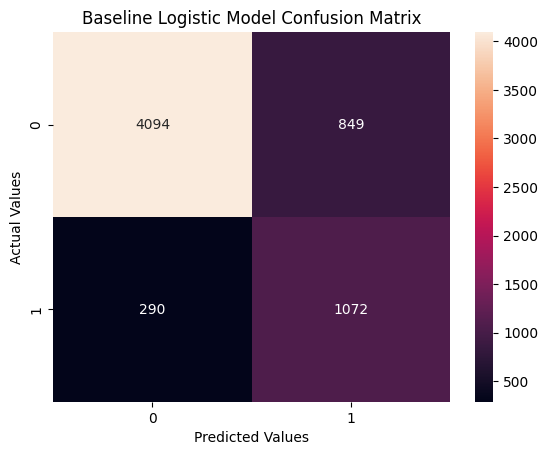

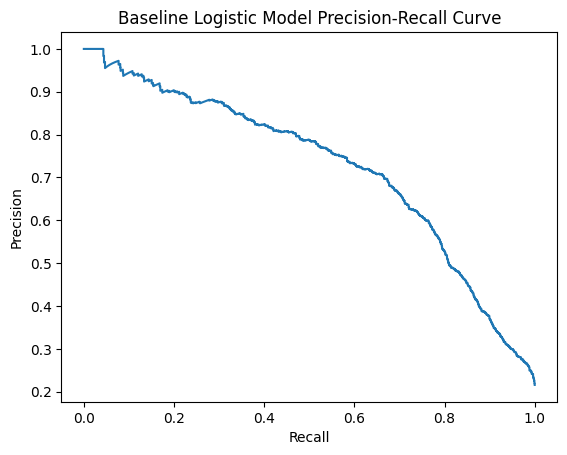

In [22]:
# Evaluate the Logistic Model.

evaluate_model("Baseline Logistic Model", baseline_model, X_test, y_test)

## 10. XGBoost Hyperparameter Tuning  ##
*   Now we move to a stronger model, XGBoost.
*   A model has many settings called hyperparameters.
*   We search for the best combination of these settings.
*   We use cross-validation while searching, so the result is reliable.



In [20]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(learning_rate=0.1, scale_pos_weight=scale_weights, random_state=42))
])

xg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   O...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

XGBoost Model Metrics:
Accuracy: 0.92
Precision: 0.82
Recall: 0.79
F1: 0.80

XGBoost Model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4943
           1       0.82      0.79      0.80      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



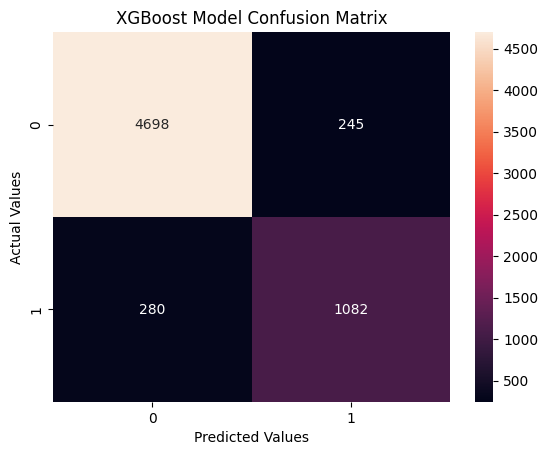

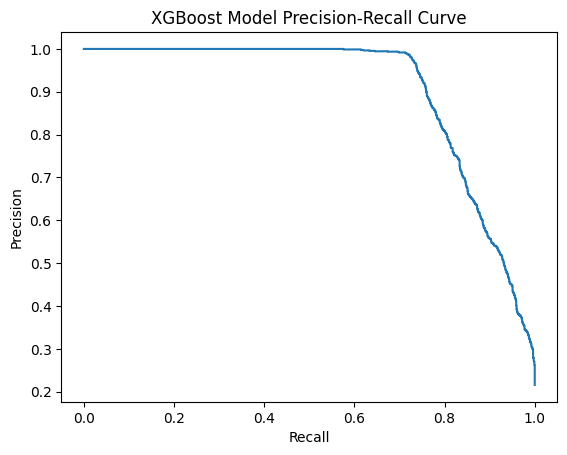

In [23]:
 # Evaluate the XGBoost Model.

evaluate_model("XGBoost Model", xg_model, X_test, y_test)

In [29]:
from scipy.stats import uniform, randint

print(np.random.randint(150, 600))

557


In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth": randint(3, 9),
    "classifier__learning_rate": uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6, 0.4), # Rows sampling
    "classifier__colsample_bytree": uniform(0.6, 0.4), # Column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0, 5)
}

# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits -> simpler tree -> low overfitting risk

In [31]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer())]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length']),
                                                                              ('cat',
                                                                               Pipeli...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa04cb31940>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fa0900b9e50>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7fa0900b8b90>},
                   scoring='average_precision', verbose=1)

In [32]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.7888111312214001),
 'classifier__gamma': np.float64(1.185715413694589),
 'classifier__learning_rate': np.float64(0.04850411425072337),
 'classifier__max_depth': 7,
 'classifier__min_child_weight': 2,
 'classifier__n_estimators': 482,
 'classifier__subsample': np.float64(0.9743624453090332)}

In [33]:
print(f"Score after performing Tunning {random_search.best_score_:.2f}")

Score after performing Tunning 0.90


## 11. Compare Both Models Side by Side  ##
*   We now compare Logistic Regression and XGBoost.
*   We look at their scores together in one table.
*   This helps us pick the better performing model.

XGBoost Model Metrics:
Accuracy: 0.92
Precision: 0.82
Recall: 0.79
F1: 0.80

XGBoost Model Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4943
           1       0.82      0.79      0.80      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



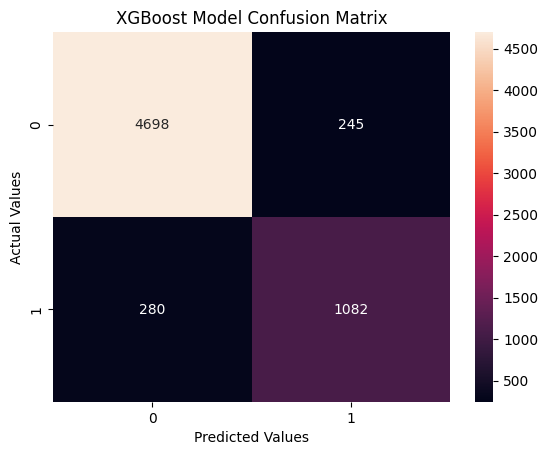

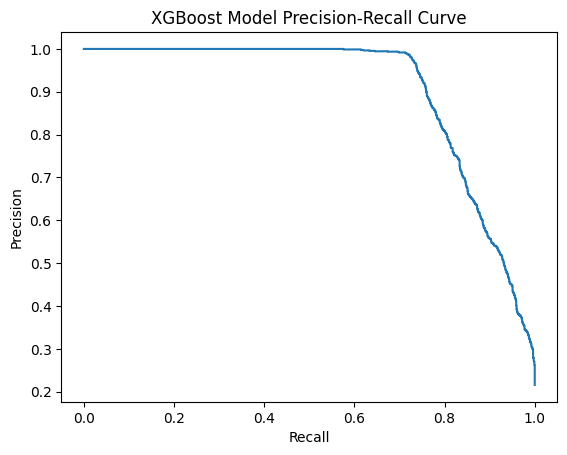

In [35]:
evaluate_model("XGBoost Model", xg_model, X_test, y_test)

XGBoost Metrics:
Accuracy: 0.92
Precision: 0.85
Recall: 0.80
F1: 0.82

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4943
           1       0.85      0.80      0.82      1362

    accuracy                           0.92      6305
   macro avg       0.90      0.88      0.89      6305
weighted avg       0.92      0.92      0.92      6305



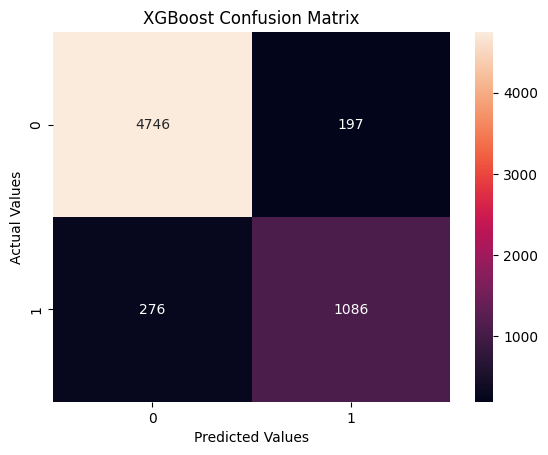

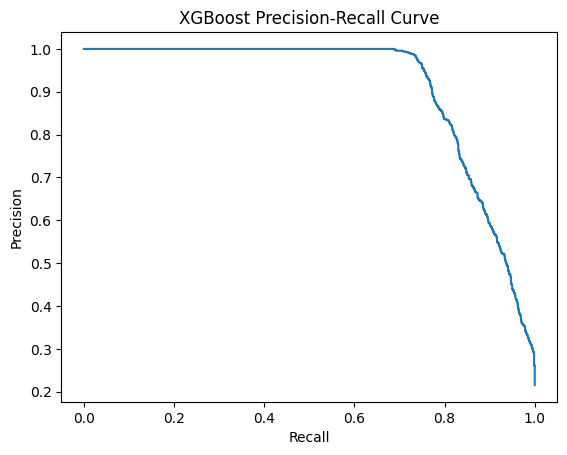

In [34]:
# Passing the XGBoost model after performing Hyperparameter Tuning

evaluate_model("XGBoost", random_search, X_test, y_test)

## 12. Optimizing the Classification Threshold  ##
*   The model gives a probability, not a direct yes or no.
*   We decide a cut-off point to turn it into a decision.
*   We check different cut-off points and pick the best one.


XGBoost Metrics:
Used Thresold : 0.71
Accuracy: 0.94
Precision: 0.97
Recall: 0.74
F1: 0.84

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.97      0.74      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.95      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



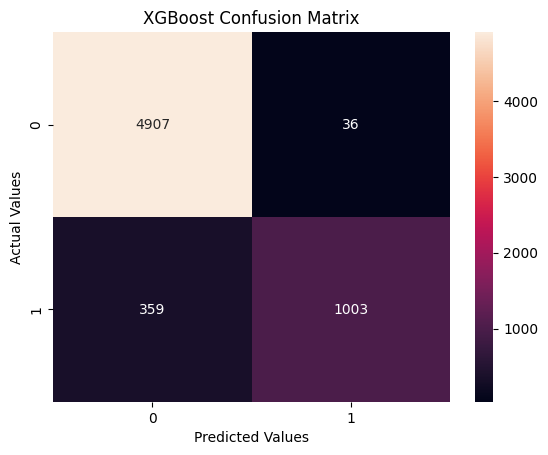

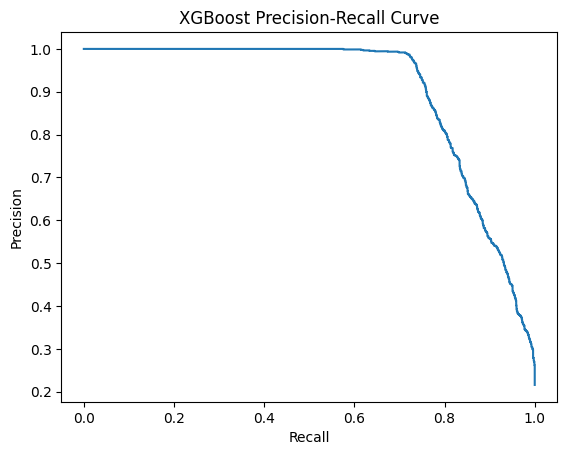

In [39]:
# Get the prob. of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

# For each threshold calculate Precision and Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, prob)

# Calculate F1 score for each threshold
f1 = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

# Evaluate the XGBoost model using that threshold.
evaluate_model("XGBoost", xg_model, X_test, y_test, best_threshold)

## 13. Probability Calibration  ##
*   Sometimes a model's probability doesn't mean what it says.
*   For example, 30% risk should truly mean a 30% chance.
*   We check this with a calibration plot.
*   We fix it if the probabilities are off.

In [ ]:
"""
Methods by which we can fix the poorly calibrated model.
1. Platt Scaling / Sigmoid -> Adjust the probabilities using a sigmoid curve.
2. Isotonic Regression -> Learn a flexible mapping from old prob. - better prob (non-linear calibration)
3. Temperature Scaling -> Adjust the confidence of neural-network predictions using one temperature.
"""

In [84]:
# 1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best_model = random_search.best_estimator_

calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5,
)

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer())]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(fill_value='Miss...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.04850411425072337),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=7,
                                                                max_leaves=None,
                                                                min_child_weight=2,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=482,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [85]:
# 2. Get probabilities

uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

In [86]:
uncalibrated

array([0.89034057, 0.19558865, 0.97784823, ..., 0.5056116 , 0.07657675,
       0.0441041 ], dtype=float32)

In [87]:
calibrated

array([0.53243566, 0.02844756, 0.96014789, ..., 0.47849076, 0.02024034,
       0.01471559])

In [88]:
# 3. Create calibration curves

actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [89]:
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins=10)

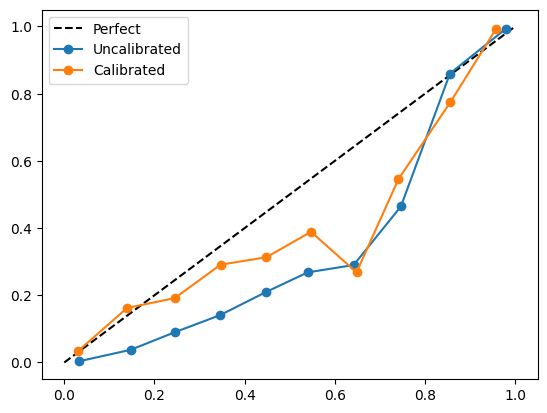

In [90]:
# 4. plot

plt.plot([0,1], [0,1], 'k--', label="Perfect")

plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label="Uncalibrated"
)

plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label="Calibrated"
)

plt.legend()

## 14. SHAP Integration - Global & Local  ##
*   SHAP helps us understand why the model makes a decision.
*   It is a way of explaining a "black box" model.


In [56]:
# 1. Install SHAP if not exists
!pip install shap

import shap

In [91]:
# 2. Get the Trained XGBoost classifier model out of the pipeline.
xgb_classifier = xg_model.named_steps['classifier']

xgb_classifier

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [92]:
# 3. Transform X_test using the same preprocessing used for training.
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [93]:
# 4. Get feature names after one-hot encoding, so plots are readable
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [94]:
# 5. Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

In [95]:
# 6. Create SHAP explainer built for tree-based model
explainer = shap.TreeExplainer(xgb_classifier)

In [96]:
# 7. Calculate SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)

shap_values

array([[-9.07786265e-02, -2.60130428e-02,  1.59890220e-01, ...,
        -5.71821211e-03, -2.85034254e-02,  0.00000000e+00],
       [-1.27930008e-03, -8.93621743e-01, -9.23981965e-02, ...,
        -8.82127322e-03, -1.00346413e-02,  0.00000000e+00],
       [ 8.06782246e-02,  3.55419803e+00,  7.90042803e-02, ...,
        -6.16901042e-03, -2.68914411e-03,  0.00000000e+00],
       ...,
       [ 1.61240064e-02,  5.96541762e-01,  1.09785624e-01, ...,
        -8.48879851e-03, -4.75517940e-03,  0.00000000e+00],
       [ 2.66249152e-03, -9.61422503e-01,  8.45184550e-02, ...,
        -8.81565548e-03, -5.45467064e-03,  0.00000000e+00],
       [-1.46226481e-01, -7.17261136e-01,  3.77279930e-02, ...,
        -8.21058918e-03, -3.19494843e-03,  0.00000000e+00]], dtype=float32)

In [97]:
shap_values[5]

# 5 -> applicant

array([ 2.2314766e-02, -8.0065739e-01, -3.2282043e-02, -2.1051740e-02,
       -5.8752447e-01, -4.3606603e-01,  2.1289345e-02, -1.9989666e-02,
       -6.0720922e-04,  8.5170507e-02, -2.8880647e-01, -3.7066743e-02,
        1.8269956e-02, -3.9563417e-02, -6.0526423e-02, -2.4830554e-02,
        1.9742553e-01,  1.1061363e-01, -1.9386341e-01,  6.0496047e-02,
       -6.4451702e-02, -2.0836128e-02, -1.2056426e-02, -9.3239415e-03,
       -8.5114427e-03,  0.0000000e+00], dtype=float32)

### Global explanation  ###
*   This shows which features matter most overall.
*   It also shows if a feature increases or decreases risk.

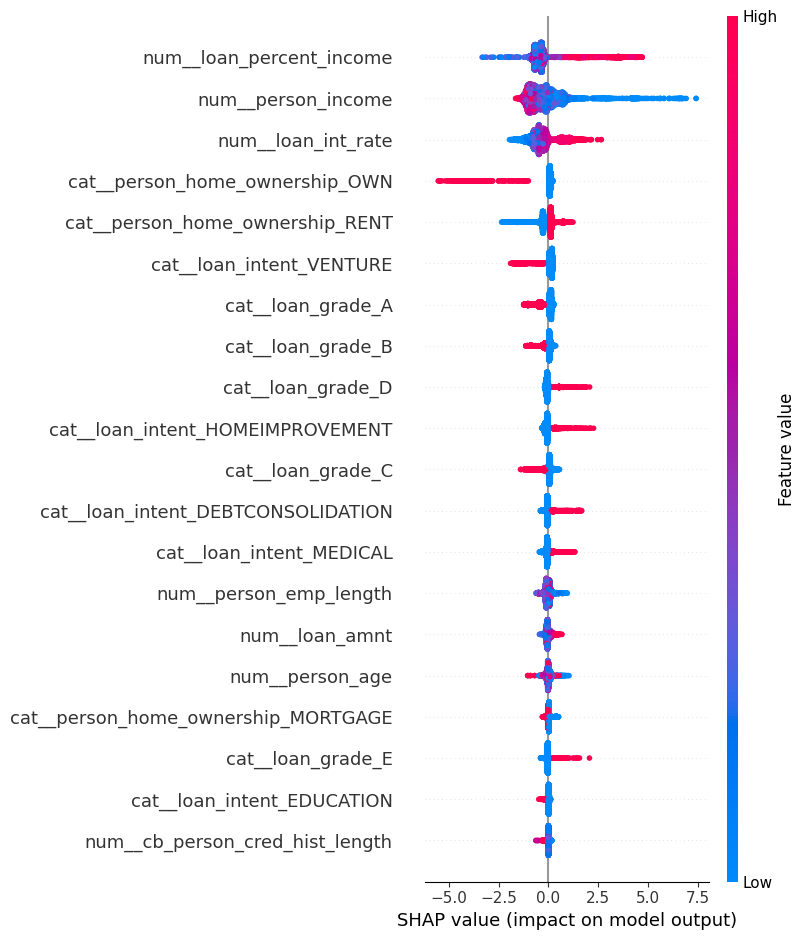

In [98]:
shap.summary_plot(shap_values, X_test_df)

### Local explanation ###
*   This shows why one specific applicant got their score.
*   It breaks the score down feature by feature.

In [99]:
X_test_df.iloc[5]

,5
num__person_age,25.00
num__person_income,60000.00
num__person_emp_length,2.00
num__loan_amnt,6900.00
num__loan_int_rate,9.99
num__loan_percent_income,0.12
num__cb_person_cred_hist_length,2.00
cat__person_home_ownership_MORTGAGE,1.00
cat__person_home_ownership_OTHER,0.00
cat__person_home_ownership_OWN,0.00


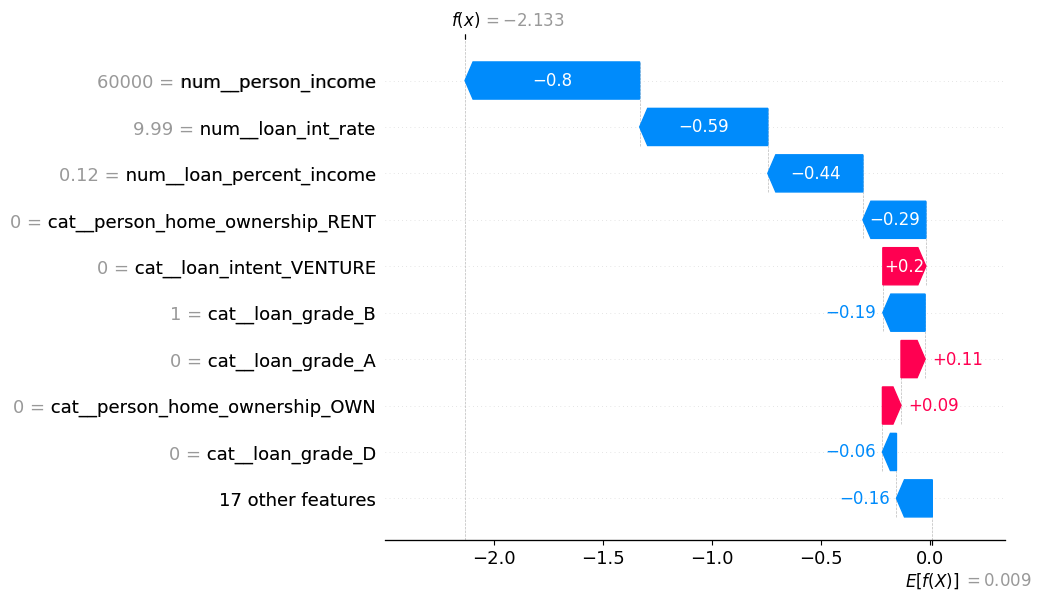

In [100]:
# 1. Pick one row to explain, e.g. the 5th applicant in the test set.
row_index = 5

# 2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

## 15. Analyzing False Positives & False Negatives  ##
*   The model will not be perfect.
*   False positives are safe people wrongly marked risky.
*   False negatives are risky people wrongly marked safe.
*   We study these cases to understand where the model struggles.



In [101]:
# Get predictions from the best performing XGBoost model on the test set
y_pred = random_search.predict(X_test)

In [102]:
# Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [103]:
result_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,actual,predicted
14455,24,30000,OWN,1.0,MEDICAL,E,15000,15.68,0.50,N,3,1,1
8701,23,60000,MORTGAGE,6.0,EDUCATION,C,25600,NaN,0.43,N,4,0,0
19804,29,18000,RENT,2.0,EDUCATION,C,3600,15.27,0.20,N,6,1,1
27252,32,130000,MORTGAGE,7.0,MEDICAL,B,13000,12.69,0.10,N,8,0,0
5610,23,45288,MORTGAGE,7.0,DEBTCONSOLIDATION,B,20500,9.25,0.45,N,2,0,0


In [104]:
# Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual'] == 0) & (result_df['predicted'] == 1)]

# Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual'] == 1) & (result_df['predicted'] == 0)]

In [105]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")

False Positive : 197
False Negative : 276


In [83]:
# False Negative > False Positive

## 16. Save the Final Model  ##
*   Once we are happy with the model, we save it.
*   We also save the settings it needs, like the chosen threshold.
*   This saved file can now be used in a real application.

In [107]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [110]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Get probabilities from the CALIBRATED model, not the old xg_model
calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

# 2. Re-run the same threshold search, now on the correct probability scale
precisions, recalls, thresholds = precision_recall_curve(y_test, calibrated_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print("New threshold:", best_threshold)

New threshold: 0.7144200176769109


In [112]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']